# Forest LULC — Deep Learning Pipeline (ResU-Net / U-Net)

**Phase 2 — runs after the RF pipeline has exported:**
- `anwiaso_s1_s2_features_2024.tif` — the 26-band feature stack
- `training_dataset.gpkg` — training polygons with `landcover` text column
- `class_mapping.json` — id→name mapping

**Model options** (set `MODEL_TYPE` in Cell 3):
- `'unet'` — fast baseline
- `'resunet'` — best accuracy (recommended)
- `'attention'` — best for rare classes (Galamsey, Road buffer)

**Runtime:** GPU (T4) — Runtime → Change runtime type → GPU

In [2]:
!pip install seaborn

In [ ]:
# CELL 1 — Install
!pip install  segmentation-models-pytorch rasterio geopandas fiona -q 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.0 MB/s eta 0:00:0000:01


In [3]:
# CELL 2 — Imports
import os, io, json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import segmentation_models_pytorch as smp

import rasterio
from rasterio.merge import merge as rio_merge
from rasterio.features import rasterize
import albumentations as A

from sklearn.metrics import (
    confusion_matrix, classification_report,
    cohen_kappa_score, accuracy_score
)
import seaborn as sns

from google.oauth2.credentials import Credentials
from google.auth.transport.requests import Request
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload, MediaFileUpload

print('✅ Imports OK')
print(f'   PyTorch : {torch.__version__}')
print(f'   GPU     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'   GPU name: {torch.cuda.get_device_name(0)}')

✅ Imports OK
   PyTorch : 2.8.0+cu128
   GPU     : True
   GPU name: Tesla T4


In [30]:
# CELL 3 — CONFIG
#
# Ensemble strategy: softmax averaging of two models with DIFFERENT encoders.
# Different encoders → genuine feature diversity → better ensemble.
#
# Model 1: UNet++ (ResU-Net)  with ResNet50     — deep, strong global context
# Model 2: MAnet (Attn UNet) with EfficientNet-B3 — lighter, sharper boundaries

MODEL_1_TYPE    = 'resunet'           # UnetPlusPlus
MODEL_1_ENCODER = 'resnet50'

ENCODER_WEIGHTS = 'imagenet'
PATCH_SIZE      = 256
PATCH_STRIDE    = 128
BATCH_SIZE      = 8
NUM_EPOCHS      = 100
LR              = 1e-4
WEIGHT_DECAY    = 1e-4
TRAIN_SPLIT     = 0.70
VAL_SPLIT       = 0.15
PATIENCE        = 15
SEED            = 42

DRIVE_FOLDER  = 'Forest_LULC_Classification'
# Auto-detects Colab, Lightning AI, or local machine
_BASE = (
    Path('/content') if Path('/content').exists() else
    Path('/teamspace/studios/this_studio') if Path('/teamspace').exists() else
    Path.home()
)
LOCAL_DIR     = _BASE / 'Forest_LULC_Classification'
OUTPUT_DIR    = LOCAL_DIR / 'DL_Results'
LOCAL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print(f'✅ CONFIG loaded  |  Device: {DEVICE}')
print(f'   Model 1 : {MODEL_1_TYPE} ({MODEL_1_ENCODER})')
print(f'   Patch   : {PATCH_SIZE}×{PATCH_SIZE}  stride={PATCH_STRIDE}')

✅ CONFIG loaded  |  Device: cuda
   Model 1 : resunet (resnet50)
   Model 2 : attention (efficientnet-b3)
   Patch   : 256×256  stride=128


In [16]:
# CELL 4 — Authenticate GEE + Drive API
#
# NEW SESSION  → uncomment ee.Authenticate(), run, paste code, comment out again.
# SAME SESSION → leave ee.Authenticate() commented; just run ee.Initialize().

import ee

ee.Authenticate(auth_mode='notebook')   # ← uncomment for new session
ee.Initialize(project='data-pipeline-1-464218')
print('✅ GEE initialised')

# Drive API — reuses credentials saved by ee.Authenticate()
_creds_path = os.path.expanduser('~/.config/earthengine/credentials')
with open(_creds_path) as f:
    _cd = json.load(f)

_drive_creds = Credentials(
    token=None, refresh_token=_cd['refresh_token'],
    token_uri='https://oauth2.googleapis.com/token',
    client_id=_cd['client_id'], client_secret=_cd['client_secret'],
    scopes=['https://www.googleapis.com/auth/drive']
)
_drive_creds.refresh(Request())
_drive_svc = build('drive', 'v3', credentials=_drive_creds)
print('✅ Drive API client ready')

def _folder_id(name):
    res = _drive_svc.files().list(
        q=f"name='{name}' and mimeType='application/vnd.google-apps.folder' and trashed=false",
        fields='files(id)'
    ).execute()
    if not res['files']:
        raise FileNotFoundError(f"Drive folder '{name}' not found.")
    return res['files'][0]['id']

def download_from_drive(filename, dest_dir=LOCAL_DIR):
    dest = Path(dest_dir) / filename
    if dest.exists():
        print(f'   Already local: {filename}')
        return str(dest)
    fid  = _folder_id(DRIVE_FOLDER)
    res  = _drive_svc.files().list(
        q=f"name='{filename}' and '{fid}' in parents and trashed=false",
        fields='files(id)'
    ).execute()
    if not res['files']:
        raise FileNotFoundError(f"'{filename}' not found in Drive/{DRIVE_FOLDER}")
    req = _drive_svc.files().get_media(fileId=res['files'][0]['id'])
    with io.FileIO(str(dest), 'wb') as fh:
        dl = MediaIoBaseDownload(fh, req)
        done = False
        while not done:
            _, done = dl.next_chunk()
    print(f'   Downloaded: {filename}')
    return str(dest)

def upload_to_drive(local_path, subfolder=None):
    local_path = Path(local_path)
    parent     = _folder_id(DRIVE_FOLDER)
    if subfolder:
        res = _drive_svc.files().list(
            q=f"name='{subfolder}' and '{parent}' in parents and mimeType='application/vnd.google-apps.folder' and trashed=false",
            fields='files(id)'
        ).execute()
        parent = res['files'][0]['id'] if res['files'] else _drive_svc.files().create(
            body={'name': subfolder, 'mimeType': 'application/vnd.google-apps.folder', 'parents': [parent]},
            fields='id'
        ).execute()['id']
    existing = _drive_svc.files().list(
        q=f"name='{local_path.name}' and '{parent}' in parents and trashed=false",
        fields='files(id)'
    ).execute()
    media = MediaFileUpload(str(local_path), resumable=True)
    if existing['files']:
        _drive_svc.files().update(fileId=existing['files'][0]['id'], media_body=media).execute()
    else:
        _drive_svc.files().create(
            body={'name': local_path.name, 'parents': [parent]},
            media_body=media, fields='id'
        ).execute()
    print(f'   Uploaded to Drive: {local_path.name}')

✅ GEE initialised
✅ Drive API client ready


In [17]:
# CELL 5 — Build / download feature stack, load, and normalise
#
# Priority: (1) already local -> (2) Drive download -> (3) build on GEE.
# Per-band min/max stats are saved so new-image prediction uses the same scale.

import time

def _mask_s2_clouds(image):
    scl  = image.select('SCL')
    mask = scl.eq(3).Or(scl.eq(8)).Or(scl.eq(9)).Or(scl.eq(10)).Not()
    return image.updateMask(mask).divide(10000).copyProperties(image, ['system:time_start'])

def _apply_speckle_filter(image):
    vv = image.select('VV').focal_mean(radius=5, kernelType='square', units='pixels').rename('VV')
    vh = image.select('VH').focal_mean(radius=5, kernelType='square', units='pixels').rename('VH')
    return image.addBands(vv, None, True).addBands(vh, None, True)

def _build_gee_features(study_area_ee, start_date, end_date, cloud_thresh=20):
    # 26-band S1+S2 feature stack, identical spec to the RF pipeline.
    s2 = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(study_area_ee).filterDate(start_date, end_date)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_thresh))
        .map(_mask_s2_clouds).median().clip(study_area_ee)
    )
    bands = s2.select(['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12'])
    NDVI  = s2.normalizedDifference(['B8','B4']).rename('NDVI')
    NDWI  = s2.normalizedDifference(['B3','B8']).rename('NDWI')
    NDRE  = s2.normalizedDifference(['B8','B5']).rename('NDRE')
    EVI   = s2.expression('2.5*((NIR-RED)/(NIR+6*RED-7.5*BLUE+1))',
        {'NIR': s2.select('B8'), 'RED': s2.select('B4'), 'BLUE': s2.select('B2')}).rename('EVI')
    SAVI  = s2.expression('1.5*(NIR-RED)/(NIR+RED+0.5)',
        {'NIR': s2.select('B8'), 'RED': s2.select('B4')}).rename('SAVI')
    NBR   = s2.normalizedDifference(['B8','B12']).rename('NBR')
    BSI   = s2.expression('((SWIR+RED)-(NIR+BLUE))/((SWIR+RED)+(NIR+BLUE))',
        {'SWIR': s2.select('B11'), 'RED': s2.select('B4'),
         'NIR': s2.select('B8'), 'BLUE': s2.select('B2')}).rename('BSI')
    s1 = (
        ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(study_area_ee).filterDate(start_date, end_date)
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
        .map(_apply_speckle_filter)
    )
    mean   = s1.select(['VV','VH']).mean().rename(['VV_mean','VH_mean'])
    mn     = s1.select(['VV','VH']).min().rename(['VV_min','VH_min'])
    mx     = s1.select(['VV','VH']).max().rename(['VV_max','VH_max'])
    std    = s1.select(['VV','VH']).reduce(ee.Reducer.stdDev()).rename(['VV_std','VH_std'])
    ratio  = mean.select('VH_mean').divide(mean.select('VV_mean')).rename('VH_VV_ratio')
    s1_feat = mean.addBands(mn).addBands(mx).addBands(std).addBands(ratio).clip(study_area_ee)
    return (bands.addBands(NDVI).addBands(NDWI).addBands(NDRE)
            .addBands(EVI).addBands(SAVI).addBands(NBR).addBands(BSI).addBands(s1_feat))


def build_feature_stack(filename, drive_folder, local_dir,
                        start_date=None, end_date=None,
                        export_crs='EPSG:32630', export_scale=10):
    # Returns local path to a GeoTIFF feature stack.
    # Falls back to GEE export when absent locally and on Drive.
    local_path = Path(local_dir) / filename
    if local_path.exists():
        print(f'Feature stack already local: {local_path}')
        return str(local_path)
    try:
        result = download_from_drive(filename, local_dir)
        print('Feature stack downloaded from Drive.')
        return result
    except FileNotFoundError:
        pass
    # -- Tiled export fallback: GEE splits large areas into tiles ----------
    # Search by prefix pattern, download all tiles, merge into one file.
    _prefix = filename.replace('.tif', '')
    try:
        _fid = _folder_id(drive_folder)
        _res = _drive_svc.files().list(
            q=f"name contains '{_prefix}' and '{_fid}' in parents "
              f"and trashed=false "
              f"and mimeType!='application/vnd.google-apps.folder'",
            fields='files(id, name)', orderBy='name'
        ).execute()
        _tiles = [f for f in _res['files'] if f['name'].endswith('.tif')]
    except Exception:
        _tiles = []
    if _tiles:
        print(f'Found {len(_tiles)} tile(s) matching "{_prefix}"')
        _paths = []
        for _f in _tiles:
            _dest = Path(local_dir) / _f['name']
            if not _dest.exists():
                _req = _drive_svc.files().get_media(fileId=_f['id'])
                with io.FileIO(str(_dest), 'wb') as _fh:
                    _dl = MediaIoBaseDownload(_fh, _req)
                    _done = False
                    while not _done:
                        _, _done = _dl.next_chunk()
                print(f'   Downloaded: {_f["name"]}')
            else:
                print(f'   Already local: {_f["name"]}')
            _paths.append(str(_dest))
        if len(_paths) == 1:
            return _paths[0]
        _datasets = [rasterio.open(p) for p in _paths]
        # Read nodata from metadata; fall back to NaN for float rasters
        # (GEE sometimes writes NaN pixels without setting the metadata flag).
        _nodata = _datasets[0].nodata
        if _nodata is None and _datasets[0].dtypes[0].startswith("float"):
            _nodata = float("nan")
        _merged, _transform = rio_merge(_datasets, nodata=_nodata)
        _out_meta = _datasets[0].meta.copy()
        _out_meta.update({'height': _merged.shape[1], 'width': _merged.shape[2],
                          'transform': _transform})
        for _ds in _datasets:
            _ds.close()
        _merged_path = str(Path(local_dir) / filename)
        with rasterio.open(_merged_path, 'w', **_out_meta) as _dst:
            _dst.write(_merged)
        print(f'{len(_paths)} tiles merged -> {filename}')
        return _merged_path
    # -----------------------------------------------------------------------
    if start_date is None or end_date is None:
        raise ValueError(
            f'{filename} not found locally or on Drive. '
            'Provide start_date and end_date to build it on GEE.'
        )
    print(f'Building feature stack on GEE ({start_date} to {end_date})')
    print('This may take 5-20 min...')
    gpkg_path = download_from_drive('study_area.gpkg', local_dir)
    gdf = gpd.read_file(gpkg_path).to_crs('EPSG:4326').dissolve()
    geom = gdf.geometry.iloc[0]
    study_area_ee = ee.Geometry(
        json.loads(gpd.GeoSeries([geom]).to_json())['features'][0]['geometry']
    )
    print(f'Study area bbox: {geom.bounds}')
    feature_image = _build_gee_features(study_area_ee, start_date, end_date)
    export_prefix = filename.replace('.tif', '')
    task = ee.batch.Export.image.toDrive(
        image=feature_image.toFloat(),
        description=export_prefix,
        folder=drive_folder,
        fileNamePrefix=export_prefix,
        region=study_area_ee,
        scale=export_scale,
        crs=export_crs,
        maxPixels=1e13,
        fileFormat='GeoTIFF'
    )
    task.start()
    print('GEE export submitted -- waiting...')
    while task.active():
        print(f'   Status: {task.status()["state"]}    ', end='\r')
        time.sleep(20)
    state = task.status()['state']
    print(f'Final state: {state}')
    if state != 'COMPLETED':
        raise RuntimeError(f'GEE export failed: {task.status().get("error_message")}')
    return download_from_drive(filename, local_dir)


# -- Load class mapping -------------------------------------------------------
try:
    mapping_path = download_from_drive('class_mapping.json')
    with open(mapping_path) as f:
        raw_mapping = json.load(f)
    id_to_name = {int(k): v for k, v in raw_mapping.items()}
    print(f'Class mapping loaded: {id_to_name}')
except FileNotFoundError:
    id_to_name = {}
    print('class_mapping.json not found -- class names will be auto-generated.')

# -- Build / download feature stack -------------------------------------------
features_path = build_feature_stack(
    filename     = 's1_s2_features_2026.tif',
    drive_folder = DRIVE_FOLDER,
    local_dir    = LOCAL_DIR,
    # Provide start_date / end_date only when the TIF is not yet on Drive:
    start_date   = '2026-03-01',
    end_date     = '2026-05-29',
)

# -- Load + normalise ---------------------------------------------------------
with rasterio.open(features_path) as src:
    features  = src.read().astype(np.float32)
    meta      = src.meta.copy()
    transform = src.transform
    crs       = src.crs

features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)

# Per-band min-max normalisation.
# Stats saved so new-image prediction uses the same scale as training.
band_min = np.zeros(features.shape[0], dtype=np.float32)
band_max = np.ones( features.shape[0], dtype=np.float32)
for b in range(features.shape[0]):
    band = features[b]
    bmin, bmax = float(band.min()), float(band.max())
    band_min[b] = bmin
    band_max[b] = bmax
    features[b] = (band - bmin) / (bmax - bmin) if bmax > bmin else 0.0

np.save(str(OUTPUT_DIR / 'band_min.npy'), band_min)
np.save(str(OUTPUT_DIR / 'band_max.npy'), band_max)
upload_to_drive(str(OUTPUT_DIR / 'band_min.npy'), subfolder='DL_Results')
upload_to_drive(str(OUTPUT_DIR / 'band_max.npy'), subfolder='DL_Results')

n_bands, H, W = features.shape
print(f'OK Feature stack loaded and normalised: {features.shape}  ({H}x{W} px, {n_bands} bands)')
print(f'   Normalisation stats saved to band_min.npy / band_max.npy')


   Already local: class_mapping.json
Class mapping loaded: {0: 'Cedrella', 1: 'Cocoa', 2: 'Degraded Forest', 3: 'Dense Forest', 4: 'Farms', 5: 'Galamsey', 6: 'Invasives', 7: 'Natural Forest', 8: 'Open Areas', 9: 'Road buffer', 10: 'Swamp'}
Feature stack already local: /content/Forest_LULC_Classification/s1_s2_features_2026.tif


   Uploaded to Drive: band_min.npy
   Uploaded to Drive: band_max.npy
OK Feature stack loaded and normalised: (26, 3533, 1651)  (3533x1651 px, 26 bands)
   Normalisation stats saved to band_min.npy / band_max.npy


In [18]:
# CELL 6 — Build label mask  (GPKG polygons or CSV point samples)
#
# Primary  : training_dataset.gpkg -- polygons rasterised to a dense pixel mask
#            (preferred; gives full spatial context for patch-based segmentation)
# Fallback : training_samples.csv  -- point samples rasterised as 3x3 px blobs
#            (use when only GEE-exported CSV point samples are available)

BAND_NAMES = [
    'B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12',
    'NDVI','NDWI','NDRE','EVI','SAVI','NBR','BSI',
    'VV_mean','VH_mean','VV_min','VH_min','VV_max','VH_max',
    'VV_std','VH_std','VH_VV_ratio',
]

MIN_POLY_OR_SAMPLES = 2    # classes below this threshold are dropped
DROP_CLASSES = ['Road buffer']  # sub-pixel at 10 m; extend as needed


def _remap_ids(id_arr, id_to_name_map, min_n):
    # Drop sparse classes and remap remaining IDs to contiguous 0-N.
    counts   = {c: int((id_arr == c).sum()) for c in np.unique(id_arr)}
    drop_ids = [c for c, n in counts.items() if n < min_n]
    if drop_ids:
        print(f'   Dropping (< {min_n}): '
              f'{[id_to_name_map.get(i, f"id={i}") for i in drop_ids]}')
        id_arr = id_arr[np.isin(id_arr, drop_ids, invert=True)]
    remaining = sorted(np.unique(id_arr).tolist())
    remap     = {old: new for new, old in enumerate(remaining)}
    return remap, remaining


def load_label_mask_gpkg(gpkg_path, feat_shape, transform, crs,
                          id_to_name_map, drop_classes=None):
    # Rasterize polygon training data to a uint8 label mask (255 = unlabelled).
    H, W = feat_shape[1], feat_shape[2]
    gdf  = gpd.read_file(gpkg_path).to_crs(crs)

    col = gdf['landcover']
    if not pd.api.types.is_numeric_dtype(col):
        names_sorted = sorted(col.dropna().unique().tolist())
        name_to_id   = {n: i for i, n in enumerate(names_sorted)}
        gdf['class_id'] = col.map(name_to_id).astype(int)
        print(f'   Text labels encoded: {name_to_id}')
    else:
        gdf['class_id'] = col.astype(int)
        name_to_id = {}

    for cls_name in (drop_classes or []):
        if cls_name in name_to_id:
            drop_id = name_to_id[cls_name]
            n = (gdf['class_id'] == drop_id).sum()
            gdf = gdf[gdf['class_id'] != drop_id].copy()
            print(f'   Dropped "{cls_name}" ({n} polygons)')

    counts   = gdf['class_id'].value_counts()
    drop_ids = counts[counts < MIN_POLY_OR_SAMPLES].index.tolist()
    if drop_ids:
        print(f'   Dropping (< {MIN_POLY_OR_SAMPLES} polygons): '
              f'{[id_to_name_map.get(i, f"id={i}") for i in drop_ids]}')
        gdf = gdf[~gdf['class_id'].isin(drop_ids)].copy()

    remaining  = sorted(gdf['class_id'].unique().tolist())
    id_remap   = {old: new for new, old in enumerate(remaining)}
    gdf['class_id'] = gdf['class_id'].map(id_remap)

    shapes_iter = ((geom, cid) for geom, cid in zip(gdf.geometry, gdf['class_id']))
    label_mask  = rasterize(shapes_iter, out_shape=(H, W),
                             transform=transform, fill=255, dtype=np.uint8)

    class_names  = [id_to_name_map.get(orig, f'Class {orig}') for orig in remaining]
    class_colors = [mcolors.to_hex(plt.cm.tab10(i % 10)) for i in range(len(remaining))]
    return label_mask, class_names, class_colors


def load_label_mask_csv(csv_path, feat_shape, transform,
                         id_to_name_map, blob_radius=1):
    # Point-sample fallback: each CSV sample is stamped as a blob so patches
    # contain enough labelled pixels.  Handles coordinate and band-value CSVs.
    H, W = feat_shape[1], feat_shape[2]
    df   = pd.read_csv(csv_path)
    print(f'   CSV: {len(df)} rows | columns: {list(df.columns[:8])}')

    has_coords = ('longitude' in df.columns or 'latitude' in df.columns
                  or '.geo' in df.columns
                  or any('lon' in c.lower() for c in df.columns))
    if not has_coords:
        raise ValueError(
            'CSV has no coordinate columns (longitude/latitude/.geo). '
            'Cannot build a spatial label mask -- use the GPKG approach instead.'
        )

    label_mask = np.full((H, W), 255, dtype=np.uint8)
    skipped    = 0
    for _, row in df.iterrows():
        try:
            if 'longitude' in df.columns and 'latitude' in df.columns:
                lon, lat = float(row['longitude']), float(row['latitude'])
            elif '.geo' in df.columns:
                geo = json.loads(row['.geo'])
                lon, lat = geo['coordinates']
            else:
                lon_col = [c for c in df.columns if 'lon' in c.lower()]
                lat_col = [c for c in df.columns if 'lat' in c.lower()]
                lon, lat = float(row[lon_col[0]]), float(row[lat_col[0]])
        except Exception:
            skipped += 1; continue

        cf, rf = ~transform * (lon, lat)
        ci, ri = int(cf), int(rf)
        if not (0 <= ri < H and 0 <= ci < W):
            skipped += 1; continue

        cls_val = int(row['landcover'])
        for dr in range(-blob_radius, blob_radius + 1):
            for dc in range(-blob_radius, blob_radius + 1):
                r2, c2 = ri + dr, ci + dc
                if 0 <= r2 < H and 0 <= c2 < W:
                    label_mask[r2, c2] = cls_val

    print(f'   Points rasterised: {(label_mask != 255).sum():,} px | skipped: {skipped}')

    raw_ids        = label_mask[label_mask != 255].astype(np.int32)
    id_remap, remaining = _remap_ids(raw_ids, id_to_name_map, MIN_POLY_OR_SAMPLES)

    remapped = np.full((H, W), 255, dtype=np.uint8)
    for old_id, new_id in id_remap.items():
        remapped[label_mask == old_id] = new_id

    class_names  = [id_to_name_map.get(orig, f'Class {orig}') for orig in remaining]
    class_colors = [mcolors.to_hex(plt.cm.tab10(i % 10)) for i in range(len(remaining))]
    return remapped, class_names, class_colors


# -- Select training data source -----------------------------------------------

try:
    gpkg_path = download_from_drive('training_dataset.gpkg')
    label_mask, CLASS_NAMES, CLASS_COLORS = load_label_mask_gpkg(
        gpkg_path, features.shape, transform, crs,
        id_to_name, drop_classes=DROP_CLASSES
    )
    print('Training source: GPKG polygons')
except FileNotFoundError:
    print('training_dataset.gpkg not found -- falling back to training_samples.csv')
    csv_path = download_from_drive('training_samples.csv')
    label_mask, CLASS_NAMES, CLASS_COLORS = load_label_mask_csv(
        csv_path, features.shape, transform, id_to_name
    )
    print('Training source: CSV point samples')

NUM_CLASSES = len(CLASS_NAMES)
labelled_px = (label_mask != 255).sum()

print(f'\nClasses ({NUM_CLASSES}):')
for i, name in enumerate(CLASS_NAMES):
    n = int((label_mask == i).sum())
    print(f'  {i:>2}  {name:<26}: {n:>8,} px ({n/labelled_px*100:.1f}%)')

print(f'\nOK Label mask created: {labelled_px:,} labelled pixels '
      f'({labelled_px/label_mask.size*100:.1f}% of image)')


   Already local: training_dataset.gpkg
   Text labels encoded: {'Cedrella': 0, 'Cocoa': 1, 'Degraded Forest': 2, 'Dense Forest': 3, 'Farms': 4, 'Galamsey': 5, 'Invasives': 6, 'Natural Forest': 7, 'Open Areas': 8, 'Road buffer': 9, 'Swamp': 10}
   Dropped "Road buffer" (15 polygons)
   Dropping (< 2 polygons): ['Cedrella']
Training source: GPKG polygons

Classes (9):
   0  Cocoa                     :   17,368 px (2.8%)
   1  Degraded Forest           :   22,061 px (3.5%)
   2  Dense Forest              :  140,970 px (22.6%)
   3  Farms                     :  178,881 px (28.7%)
   4  Galamsey                  :    5,086 px (0.8%)
   5  Invasives                 :   92,708 px (14.9%)
   6  Natural Forest            :   19,915 px (3.2%)
   7  Open Areas                :  138,806 px (22.3%)
   8  Swamp                     :    6,990 px (1.1%)

OK Label mask created: 622,785 labelled pixels (10.7% of image)


In [19]:
# CELL 7 — Extract patches

image_patches, label_patches = [], []

for r in range(0, H - PATCH_SIZE + 1, PATCH_STRIDE):
    for c in range(0, W - PATCH_SIZE + 1, PATCH_STRIDE):
        lp = label_mask[r:r+PATCH_SIZE, c:c+PATCH_SIZE]
        if np.any(lp != 255):   # keep patches with at least one labelled pixel
            image_patches.append(features[:, r:r+PATCH_SIZE, c:c+PATCH_SIZE])
            label_patches.append(lp)

image_patches = np.array(image_patches)  # (N, C, H, W)
label_patches = np.array(label_patches)  # (N, H, W)

print(f'✅ {len(image_patches)} patches extracted  ({PATCH_SIZE}×{PATCH_SIZE}, stride={PATCH_STRIDE})')

✅ 150 patches extracted  (256×256, stride=128)


In [20]:
# CELL 8 — Dataset & DataLoaders

class ForestDataset(Dataset):
    def __init__(self, images, labels, augment=False):
        self.images  = images
        self.labels  = labels
        self.aug     = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
        ]) if augment else None

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.float32)
        lbl = self.labels[idx].astype(np.int64)
        if self.aug:
            aug = self.aug(image=np.transpose(img, (1,2,0)), mask=lbl)
            img = np.transpose(aug['image'], (2,0,1))
            lbl = aug['mask'].astype(np.int64)   # re-cast — albumentations drops int64
        return torch.tensor(img), torch.tensor(lbl).long()   # .long() = int64 = required by CrossEntropyLoss

N       = len(image_patches)
n_train = int(N * TRAIN_SPLIT)
n_val   = int(N * VAL_SPLIT)
n_test  = N - n_train - n_val

rng  = np.random.default_rng(SEED)
idx  = rng.permutation(N)
tr_i = idx[:n_train]
va_i = idx[n_train:n_train+n_val]
te_i = idx[n_train+n_val:]

train_loader = DataLoader(ForestDataset(image_patches[tr_i], label_patches[tr_i], augment=True),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(ForestDataset(image_patches[va_i], label_patches[va_i], augment=False),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(ForestDataset(image_patches[te_i], label_patches[te_i], augment=False),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'✅ Dataset split — Train: {n_train} | Val: {n_val} | Test: {n_test}')

✅ Dataset split — Train: 105 | Val: 22 | Test: 23


In [32]:
# CELL 9 — Build both models + class weights

def build_model(model_type, encoder):
    kwargs = dict(
        encoder_name=encoder,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=n_bands,
        classes=NUM_CLASSES,
        activation=None
    )
    if model_type == 'unet':
        return smp.Unet(**kwargs)
    elif model_type == 'resunet':
        return smp.UnetPlusPlus(**kwargs)
    elif model_type == 'attention':
        return smp.MAnet(**kwargs)
    raise ValueError(f'Unknown model_type: {model_type}')

model1 = build_model(MODEL_1_TYPE, MODEL_1_ENCODER).to(DEVICE)

p1 = sum(p.numel() for p in model1.parameters())
print(f'Model — {MODEL_1_TYPE.upper()} / {MODEL_1_ENCODER} : {p1:,} parameters')

# Balanced class weights: n_samples / (n_classes * class_count)
# Same formula as sklearn class_weight="balanced" — works at any pixel scale.
valid  = label_patches[label_patches != 255]
counts = np.bincount(valid, minlength=NUM_CLASSES).astype(float)
counts = np.where(counts == 0, 1, counts)
w      = counts.sum() / (NUM_CLASSES * counts)
w      = np.clip(w, 0.1, 10.0)          # cap: rarest class gets at most 100x most common
w      = w / w.mean()                   # normalise so mean weight = 1
class_weights = torch.tensor(w, dtype=torch.float32).to(DEVICE)

print('\nClass weights:')
for i, (name, wt) in enumerate(zip(CLASS_NAMES, w)):
    print(f'  {i:>2}  {name:<26}: {wt:.3f}')

Model — RESUNET / resnet50 : 49,059,033 parameters

Class weights:
   0  Cocoa                     : 1.106
   1  Degraded Forest           : 0.808
   2  Dense Forest              : 0.139
   3  Farms                     : 0.113
   4  Galamsey                  : 2.799
   5  Invasives                 : 0.206
   6  Natural Forest            : 0.895
   7  Open Areas                : 0.135
   8  Swamp                     : 2.799



  TRAINING RESUNET/RESNET50
  Epoch   1/100  train=2.1066  val=1.9859  ✅ saved
  Epoch   2/100  train=1.8191  val=1.8698  ✅ saved
  Epoch   3/100  train=1.7586  val=1.7853  ✅ saved
  Epoch   4/100  train=1.6726  val=1.6703  ✅ saved
  Epoch   5/100  train=1.5861  val=1.5920  ✅ saved
  Epoch   6/100  train=1.5309  val=1.7148
  Epoch   7/100  train=1.4772  val=1.4751  ✅ saved
  Epoch   8/100  train=1.4469  val=1.4741  ✅ saved
  Epoch   9/100  train=1.4074  val=1.4989
  Epoch  10/100  train=1.4473  val=1.5797
  Epoch  11/100  train=1.3442  val=1.3974  ✅ saved
  Epoch  12/100  train=1.3744  val=1.4086
  Epoch  13/100  train=1.3386  val=1.2883  ✅ saved
  Epoch  14/100  train=1.2991  val=1.2534  ✅ saved
  Epoch  15/100  train=1.2565  val=1.2358  ✅ saved
  Epoch  16/100  train=1.2644  val=1.2595
  Epoch  17/100  train=1.2398  val=1.2159  ✅ saved
  Epoch  18/100  train=1.1958  val=1.2482
  Epoch  19/100  train=1.1753  val=1.1486  ✅ saved
  Epoch  20/100  train=1.1341  val=1.1844
  Epoch  21/10

ValueError: not enough values to unpack (expected 4, got 2)

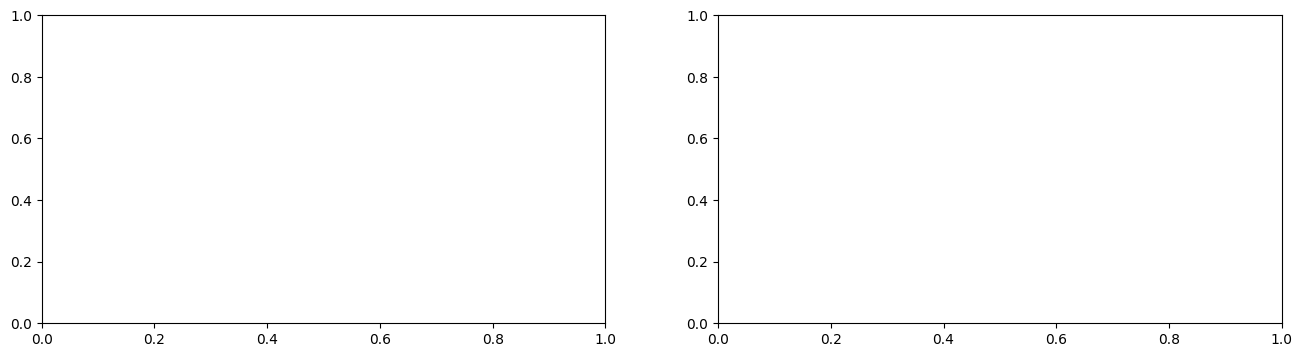

In [34]:
# CELL 10 — Train both models

def train_model(model, model_name, train_loader, val_loader, class_weights, ckpt_path):
    # FocalLoss focuses on hard examples; weighted CE balances rare classes.
    # smp FocalLoss alpha does not support per-class lists in multiclass mode.
    # Equal-weighted combination: focal handles hard pixels, CE handles class balance
    _focal = smp.losses.FocalLoss(mode="multiclass", gamma=2.0, ignore_index=255)
    _ce    = nn.CrossEntropyLoss(weight=class_weights, ignore_index=255)
    criterion = lambda pred, tgt: 0.5 * _focal(pred, tgt) + 0.5 * _ce(pred, tgt)
    optimizer  = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 'min', factor=0.5, patience=5)

    best_val   = float('inf')
    patience_c = 0
    tr_losses, va_losses = [], []

    print(f'\n{"="*55}')
    print(f'  TRAINING {model_name.upper()}')
    print(f'{"="*55}')

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        tl = 0.0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), lbls)
            loss.backward()
            optimizer.step()
            tl += loss.item()
        tl /= len(train_loader)

        model.eval()
        vl = 0.0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                vl += criterion(model(imgs), lbls).item()
        vl /= len(val_loader)
        scheduler.step(vl)

        tr_losses.append(tl)
        va_losses.append(vl)
        print(f'  Epoch {epoch:>3}/{NUM_EPOCHS}  train={tl:.4f}  val={vl:.4f}',
              end='')

        if vl < best_val:
            best_val   = vl
            patience_c = 0
            torch.save(model.state_dict(), ckpt_path)
            print('  ✅ saved')
        else:
            patience_c += 1
            print()
            if patience_c >= PATIENCE:
                print(f'  Early stopping at epoch {epoch}')
                break

    print(f'\n✅ {model_name.upper()} done.  Best val loss: {best_val:.4f}')
    upload_to_drive(ckpt_path, subfolder='DL_Results')
    return tr_losses, va_losses

ckpt1 = str(OUTPUT_DIR / 'model1_best.pth')

tr1, va1 = train_model(
    model1, f'{MODEL_1_TYPE}/{MODEL_1_ENCODER}',
    train_loader, val_loader, class_weights, ckpt1
)

# Plot training curves
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
for ax, tr, va, name in zip(
    [ax],
    [tr1],
    [va1],
    [f'{MODEL_1_TYPE}/{MODEL_1_ENCODER}'],
):
    ax.plot(tr, label='Train', color='#1a6600', linewidth=2)
    ax.plot(va, label='Val',   color='#ff4400', linewidth=2)
    ax.set_title(f'{name} — Training Curves')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend()
plt.tight_layout()
curve_path = str(OUTPUT_DIR / 'training_curves.png')
plt.savefig(curve_path, dpi=150); plt.show()
upload_to_drive(curve_path, subfolder='DL_Results')

Best val loss: 0.5224


Model: resunet / resnet50
  Overall Accuracy : 75.21%
  Cohen's Kappa    : 0.6792

                 precision    recall  f1-score   support

          Cocoa      0.711     0.724     0.717      6364
Degraded Forest      0.828     0.932     0.877      5103
   Dense Forest      0.818     0.774     0.795     85712
          Farms      0.731     0.497     0.592     69264
       Galamsey      0.527     0.506     0.516       176
      Invasives      0.612     0.870     0.718     59908
 Natural Forest      0.548     0.424     0.478      1761
     Open Areas      0.924     0.927     0.925     48448
          Swamp      0.590     0.828     0.689      2705

       accuracy                          0.752    279441
      macro avg      0.699     0.720     0.701    279441
   weighted avg      0.764     0.752     0.747    279441



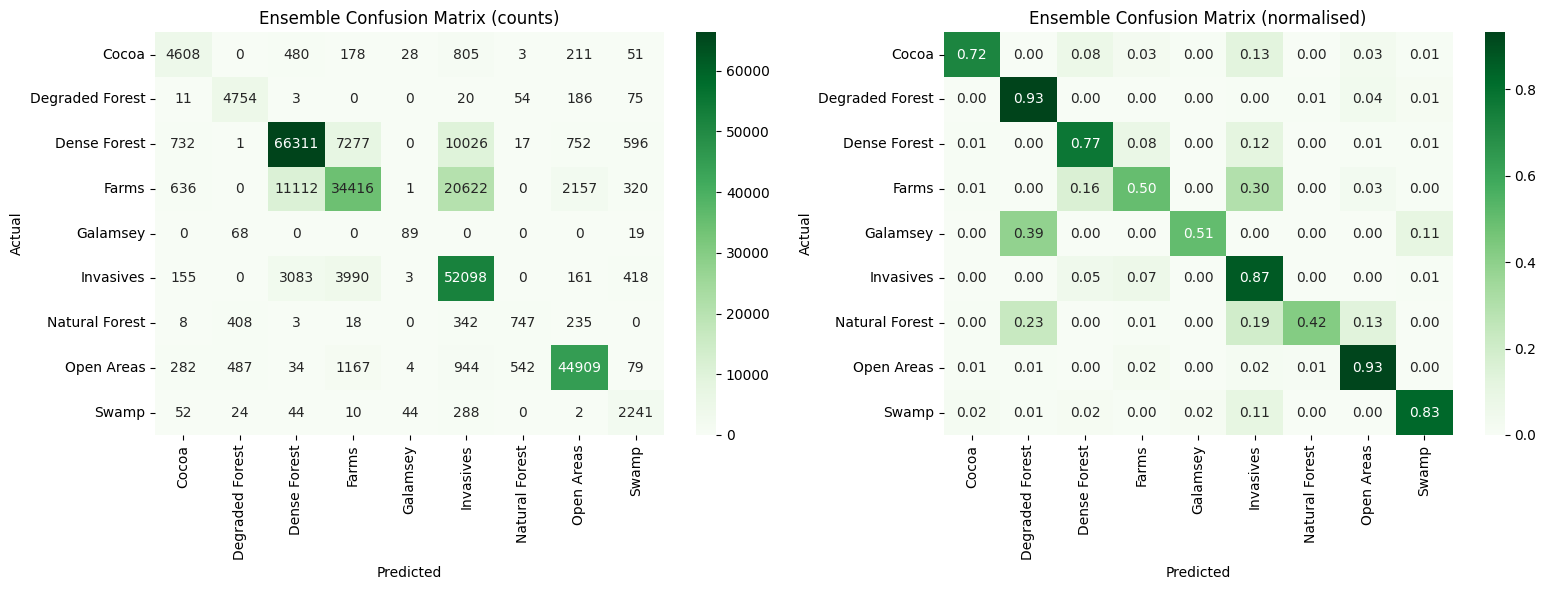

   Uploaded to Drive: dl_ensemble_confusion_matrix.png


In [35]:
# CELL 11 — Accuracy assessment (softmax averaging ensemble)
#
# Both models predict softmax probabilities; we combine them with
# inverse-loss weights so the stronger model contributes more.

model1.load_state_dict(torch.load(ckpt1, map_location=DEVICE))
model1.eval()
print(f'Best val loss: {min(va1):.4f}')

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(DEVICE)
        probs = F.softmax(model1(imgs), dim=1)
        preds = torch.argmax(probs, dim=1).cpu().numpy()
        lbls  = lbls.numpy()
        mask  = lbls != 255
        all_preds.append(preds[mask])
        all_labels.append(lbls[mask])

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

oa    = accuracy_score(all_labels, all_preds)
kappa = cohen_kappa_score(all_labels, all_preds)

print(f'Model: {MODEL_1_TYPE} / {MODEL_1_ENCODER}')
print(f'  Overall Accuracy : {oa*100:.2f}%')
print(f"  Cohen's Kappa    : {kappa:.4f}")
print()
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES, digits=3))

cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
short   = [n.split('/')[0].strip() for n in CLASS_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm,      annot=True, fmt='d',   cmap='Greens',
            xticklabels=short, yticklabels=short, ax=axes[0])
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=short, yticklabels=short, ax=axes[1])
axes[0].set(title='Ensemble Confusion Matrix (counts)',
            ylabel='Actual', xlabel='Predicted')
axes[1].set(title='Ensemble Confusion Matrix (normalised)',
            ylabel='Actual', xlabel='Predicted')
plt.tight_layout()
cm_path = str(OUTPUT_DIR / 'dl_ensemble_confusion_matrix.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight'); plt.show()
upload_to_drive(cm_path, subfolder='DL_Results')

In [36]:
# CELL 12 — Full image prediction (inverse-loss weighted ensemble)

model1.load_state_dict(torch.load(ckpt1, map_location=DEVICE))
model1.eval()

score_map = np.zeros((NUM_CLASSES, H, W), dtype=np.float32)
count_map = np.zeros((H, W),              dtype=np.float32)

print('Predicting full image with softmax averaging ensemble (sliding window)...')
total_windows = (
    len(range(0, H - PATCH_SIZE + 1, PATCH_STRIDE)) *
    len(range(0, W - PATCH_SIZE + 1, PATCH_STRIDE))
)
done = 0

with torch.no_grad():
    for r in range(0, H - PATCH_SIZE + 1, PATCH_STRIDE):
        for c in range(0, W - PATCH_SIZE + 1, PATCH_STRIDE):
            patch = torch.tensor(
                features[:, r:r+PATCH_SIZE, c:c+PATCH_SIZE]
            ).unsqueeze(0).to(DEVICE)
            probs = F.softmax(model1(patch), dim=1).squeeze(0).cpu().numpy()
            score_map[:, r:r+PATCH_SIZE, c:c+PATCH_SIZE] += probs
            count_map[r:r+PATCH_SIZE,    c:c+PATCH_SIZE] += 1
            done += 1
            if done % 50 == 0:
                print(f'  {done/total_windows*100:.0f}%', end='\r')

count_map  = np.where(count_map == 0, 1, count_map)
avg_probs  = score_map / count_map[np.newaxis]   # (C, H, W) normalised scores
max_prob   = avg_probs.max(axis=0)               # per-pixel peak confidence
pred_map   = avg_probs.argmax(axis=0).astype(np.uint8)
print('Full image predicted — all pixels classified (no confidence mask)')

out_meta = meta.copy()
out_meta.update({'count': 1, 'dtype': 'uint8', 'nodata': 255})
tif_path = str(OUTPUT_DIR / 'dl_ensemble_classification_2024.tif')
with rasterio.open(tif_path, 'w', **out_meta) as dst:
    dst.write(pred_map[np.newaxis])
upload_to_drive(tif_path, subfolder='DL_Results')
print('GeoTIFF uploaded: dl_ensemble_classification_2024.tif')

Predicting full image with softmax averaging ensemble (sliding window)...
Full image predicted — all pixels classified (no confidence mask)
   Uploaded to Drive: dl_ensemble_classification_2024.tif
GeoTIFF uploaded: dl_ensemble_classification_2024.tif


In [37]:
# CELL 13 — Generalise, vectorise & save GeoPackage (DL classification)
#
# Applies the same post-processing as the RF pipeline:
#   1. Majority filter  (remove salt-and-pepper)
#   2. MMU absorption   (absorb tiny patches into neighbours)
#   3. Vectorise        (raster → vector polygons)
#   4. Simplify + dissolve by class
#   5. Save GeoPackage with two layers: lulc_patches + lulc_by_class

from rasterio.features import shapes
from shapely.geometry import shape
from skimage.morphology import disk
from skimage.filters.rank import majority as majority_filter_sk
from scipy.ndimage import label as nd_label, distance_transform_edt

MAJORITY_RADIUS = 2
MMU_PIXELS      = 100
SIMPLIFY_TOL    = 10

def absorb_small_patches(arr, mmu_pixels):
    nodata_mask = (arr == 255)
    small_mask  = np.zeros(arr.shape, dtype=bool)
    for cls_val in np.unique(arr[~nodata_mask]):
        labeled, n = nd_label(arr == cls_val)
        for region_id in range(1, n + 1):
            if (labeled == region_id).sum() < mmu_pixels:
                small_mask |= (labeled == region_id)
    pixels_to_fill = small_mask & ~nodata_mask
    if not pixels_to_fill.any():
        print("         No patches below MMU — nothing to absorb")
        return arr
    invalid = small_mask | nodata_mask
    _, nearest_idx = distance_transform_edt(invalid, return_indices=True)
    result     = arr.copy()
    rows, cols = np.where(pixels_to_fill)
    result[rows, cols] = arr[nearest_idx[0][rows, cols], nearest_idx[1][rows, cols]]
    print(f"         Absorbed {pixels_to_fill.sum():,} px ({pixels_to_fill.sum() / arr.size * 100:.2f}% of image) into neighbours")
    return result


transform     = meta["transform"]
crs_str       = meta["crs"]
pixel_area_m2 = abs(transform.a * transform.e)
mmu_ha        = MMU_PIXELS * pixel_area_m2 / 10_000

print(f"Step 1 — Majority filter  (radius={MAJORITY_RADIUS} px)...")
smoothed = majority_filter_sk(pred_map.astype(np.uint8), disk(MAJORITY_RADIUS))
print(f"         Unique classes after filter: {np.unique(smoothed).tolist()}")

print(f"Step 2 — MMU absorption  ({MMU_PIXELS} px = {mmu_ha:.4f} ha)...")
smoothed = absorb_small_patches(smoothed, MMU_PIXELS)

print("Step 3 — Vectorising...")
valid_mask = (smoothed != 255).astype(np.uint8)
raw_shapes = list(shapes(smoothed, mask=valid_mask, transform=transform))
print(f"         Raw patches: {len(raw_shapes):,}")

records = [{"geometry": shape(geom), "class_id": int(val)} for geom, val in raw_shapes]
gdf_dl  = gpd.GeoDataFrame(records, crs=crs_str)

print(f"Step 4 — Simplifying geometry  (tolerance={SIMPLIFY_TOL} m)...")
gdf_dl["geometry"] = gdf_dl.geometry.simplify(tolerance=SIMPLIFY_TOL, preserve_topology=True)

gdf_dl["class_name"]  = gdf_dl["class_id"].apply(lambda i: CLASS_NAMES[i] if i < len(CLASS_NAMES) else "Unknown")
gdf_dl["class_color"] = gdf_dl["class_id"].apply(lambda i: CLASS_COLORS[i] if i < len(CLASS_COLORS) else "#888888")
gdf_dl_utm            = gdf_dl.to_crs("EPSG:32630")
gdf_dl["area_ha"]     = gdf_dl_utm.geometry.area / 10_000

print("Step 5 — Dissolving by class...")
gdf_dl_dissolved = gdf_dl.dissolve(by="class_id", aggfunc={"area_ha": "sum"}).reset_index()
gdf_dl_dissolved["class_name"]  = gdf_dl_dissolved["class_id"].apply(lambda i: CLASS_NAMES[i] if i < len(CLASS_NAMES) else "Unknown")
gdf_dl_dissolved["class_color"] = gdf_dl_dissolved["class_id"].apply(lambda i: CLASS_COLORS[i] if i < len(CLASS_COLORS) else "#888888")
gdf_dl_dissolved["geometry"]    = gdf_dl_dissolved.geometry.simplify(tolerance=SIMPLIFY_TOL, preserve_topology=True)

gpkg_out = str(OUTPUT_DIR / "dl_lulc_classification.gpkg")
gdf_dl.to_file(          gpkg_out, layer="lulc_patches",  driver="GPKG")
gdf_dl_dissolved.to_file(gpkg_out, layer="lulc_by_class", driver="GPKG")
upload_to_drive(gpkg_out, subfolder="DL_Results")

print()
print("✅ GeoPackage saved:", gpkg_out)
print("   lulc_patches   —", len(gdf_dl), "individual patches")
print("   lulc_by_class  —", len(gdf_dl_dissolved), "class polygons")

total_ha = gdf_dl_dissolved["area_ha"].sum()
sep = "─" * 56
print()
print(sep)
print("  {:<26}  {:>7}  {:>10}  {:>7}".format("Class", "Patches", "Area (ha)", "% Total"))
print(sep)
for _, row in gdf_dl_dissolved.sort_values("class_id").iterrows():
    pct     = row["area_ha"] / total_ha * 100
    n_patch = (gdf_dl["class_id"] == row["class_id"]).sum()
    bar     = "█" * int(pct / 2.5)
    name    = row["class_name"]
    area    = row["area_ha"]
    print("  {:<26}  {:>7,}  {:>10,.1f}  {:>6.1f}%  {}".format(name, n_patch, area, pct, bar))
print(sep)
print("  {:<26}  {:>7,}  {:>10,.1f}  {:>7}".format("TOTAL", len(gdf_dl), total_ha, "100.0%"))

Step 1 — Majority filter  (radius=2 px)...


         Unique classes after filter: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Step 2 — MMU absorption  (100 px = 1.0000 ha)...
         Absorbed 209,499 px (3.59% of image) into neighbours
Step 3 — Vectorising...
         Raw patches: 2,825
Step 4 — Simplifying geometry  (tolerance=10 m)...
Step 5 — Dissolving by class...
   Uploaded to Drive: dl_lulc_classification.gpkg

✅ GeoPackage saved: /content/Forest_LULC_Classification/DL_Results/dl_lulc_classification.gpkg
   lulc_patches   — 2825 individual patches
   lulc_by_class  — 9 class polygons

────────────────────────────────────────────────────────
  Class                       Patches   Area (ha)  % Total
────────────────────────────────────────────────────────
  Cocoa                            84    37,040.6    63.5%  █████████████████████████
  Degraded Forest                  12       341.6     0.6%  
  Dense Forest                    783     7,717.7    13.2%  █████
  Farms                           691     3,191.6     5.5%  ██
  Galamsey 

In [ ]:
# CELL 14 — Visualise + results summary

cmap           = mcolors.ListedColormap(CLASS_COLORS)
patches_legend = [mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i])
                  for i in range(NUM_CLASSES)]

plt.figure(figsize=(12, 10))
plt.imshow(pred_map, cmap=cmap, vmin=0, vmax=NUM_CLASSES - 1)
plt.legend(handles=patches_legend, bbox_to_anchor=(1.02, 1),
           loc='upper left', fontsize=9)
plt.title(
    f'LULC Classification 2024\n'
    f'{MODEL_1_TYPE.upper()} ({MODEL_1_ENCODER}) + '
    f'Softmax Averaging Ensemble'
)
plt.axis('off')
plt.tight_layout()
png_path = str(OUTPUT_DIR / 'dl_ensemble_classification_2024.png')
plt.savefig(png_path, dpi=200, bbox_inches='tight')
plt.show()
upload_to_drive(png_path, subfolder='DL_Results')

# Upload both model weights
upload_to_drive(ckpt1, subfolder='DL_Results')

print(f'\n╔══════════════════════════════════════════════════════╗')
print(f'║  SOFTMAX AVERAGING ENSEMBLE — RESULTS                ║')
print(f'╠══════════════════════════════════════════════════════╣')
print(f'║  Model 1 : {MODEL_1_TYPE.upper()} / {MODEL_1_ENCODER:<34}║')
print(print(f'║  Overall Accuracy : {oa*100:.2f}%{"":>33}║')
print(f"║  Cohen's Kappa    : {kappa:.4f}{'':>33}║")
print(f'╠══════════════════════════════════════════════════════╣')
print(f'║  Files in Drive/DL_Results/:                         ║')
print(f'║    dl_ensemble_classification_2024.tif   — GeoTIFF   ║')
print(f'║    dl_ensemble_confusion_matrix.png      — accuracy  ║')
print(f'║    dl_ensemble_classification_2024.png   — map       ║')
print(f'║    training_curves.png                   — loss      ║')
print(f'║    model1_best.pth  (ResU-Net/ResNet50)  — weights   ║')
print(print(f'╚══════════════════════════════════════════════════════╝')

## NEW IMAGE PREDICTION
### Apply the trained ensemble to a different date range or season

**Run Cells 1-14 first** (training pipeline), then continue here to:
1. Configure a new date range in `NI_CFG` (Cell 15)
2. Build a fresh Sentinel-1 + Sentinel-2 feature stack on GEE (Cell 16)
3. Download and normalise with **training image stats** to prevent distribution shift (Cell 17)
4. Run the softmax averaging ensemble, post-process, and save results (Cell 18)

The trained `model1` / `model2` objects from Cell 10 are reused directly.  
To reload saved weights instead, uncomment the two `load_state_dict` lines in Cell 16.

In [12]:
# CELL 15 -- New image CONFIG
# Change start_date / end_date to target a different season or year.
# Change export_prefix to avoid overwriting a previous export.

NI_CFG = {
    'gee_project':    'data-pipeline-1-464218',

    # Study area GeoPackage (must already be in your Drive folder)
    'gpkg_filename':  'phase2.gpkg',
    'gpkg_layer':     None,

    # Date range -- dry season (Nov-Feb) gives cleanest imagery for Ghana
    'start_date':   '2026-3-01',
    'end_date':     '2026-05-29',
    'cloud_thresh':   20,

    # Export settings -- must match the training feature stack
    'export_crs':     'EPSG:32630',
    'export_scale':   10,
    'drive_folder':   'Forest_LULC_Classification',
    'export_prefix':  'phase2_s1_s2_features',

    # Post-processing (same defaults as training pipeline)
    'majority_radius': 2,
    'mmu_pixels':      100,
    'simplify_tol':    10,

    # Auto-detects Colab, Lightning AI, or local machine
    'local_dir':   (Path('/content') if Path('/content').exists() else
                   Path('/teamspace/studios/this_studio') if Path('/teamspace').exists() else
                   Path.home()) / 'Forest_LULC_Classification',
    'output_dir':  (Path('/content') if Path('/content').exists() else
                   Path('/teamspace/studios/this_studio') if Path('/teamspace').exists() else
                   Path.home()) / 'Forest_LULC_Classification/NewImage_Results',
}

NI_CFG['local_dir'].mkdir(exist_ok=True)
NI_CFG['output_dir'].mkdir(exist_ok=True)

print('OK New image CONFIG loaded')
print(f'   Date range : {NI_CFG["start_date"]} to {NI_CFG["end_date"]}')
print(f'   Export     : {NI_CFG["export_prefix"]}.tif  Drive/{NI_CFG["drive_folder"]}')


OK New image CONFIG loaded
   Date range : 2026-3-01 to 2026-05-29
   Export     : phase2_s1_s2_features.tif  Drive/Forest_LULC_Classification


In [15]:
# CELL 15b -- Load trained models from Drive
#
# Run this cell (after Cell 15) to prepare everything needed for
# Cells 16-18 WITHOUT running the full training pipeline (Cells 1-14).
# Requires: ee.Authenticate() already completed once so that
#           ~/.config/earthengine/credentials exists on this machine.

import os, io, json, time
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import rasterio
from pathlib import Path

import torch
import torch.nn.functional as F
import segmentation_models_pytorch as smp

from google.oauth2.credentials import Credentials
from google.auth.transport.requests import Request
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload, MediaFileUpload
import ee

# ── Architecture constants (must match training CONFIG) ────────────────────
MODEL_1_TYPE    = 'resunet'
MODEL_1_ENCODER = 'resnet50'
ENCODER_WEIGHTS = 'imagenet'
PATCH_SIZE      = 256
PATCH_STRIDE    = 128
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_bands = 26
print(f'Device: {DEVICE}')

# ── Local directories ──────────────────────────────────────────────────────
# Auto-detects Colab, Lightning AI, or local machine
_BASE = (
    Path('/content') if Path('/content').exists() else
    Path('/teamspace/studios/this_studio') if Path('/teamspace').exists() else
    Path.home()
)
LOCAL_DIR  = _BASE / 'Forest_LULC_Classification'
OUTPUT_DIR = LOCAL_DIR / 'DL_Results'
LOCAL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# ── GEE + Drive API ────────────────────────────────────────────────────────
# NEW SESSION  -> uncomment ee.Authenticate(), run, paste code, comment out.
# SAME SESSION -> leave it commented; ee.Initialize() is enough.
ee.Authenticate(auth_mode='notebook')   # <- uncomment for a new session
ee.Initialize(project=NI_CFG['gee_project'])

if '_drive_svc' not in vars():
    _creds_path = os.path.expanduser('~/.config/earthengine/credentials')
    with open(_creds_path) as _f:
        _cd = json.load(_f)
    _drive_creds = Credentials(
        token=None, refresh_token=_cd['refresh_token'],
        token_uri='https://oauth2.googleapis.com/token',
        client_id=_cd['client_id'], client_secret=_cd['client_secret'],
        scopes=['https://www.googleapis.com/auth/drive']
    )
    _drive_creds.refresh(Request())
    _drive_svc = build('drive', 'v3', credentials=_drive_creds)
    print('GEE + Drive API initialized')


def _ni_folder_id(folder_name=None):
    name = folder_name or NI_CFG['drive_folder']
    res  = _drive_svc.files().list(
        q=f"name='{name}' and "
          f"mimeType='application/vnd.google-apps.folder' and trashed=false",
        fields='files(id)'
    ).execute()
    if not res['files']:
        raise FileNotFoundError(f"Drive folder '{name}' not found.")
    return res['files'][0]['id']


def ni_download(filename, dest_dir=None, subfolder=None):
    # Search order: subfolder hint -> Drive folder root -> global Drive search.
    dest_dir = Path(dest_dir or NI_CFG['local_dir'])
    dest_dir.mkdir(exist_ok=True)
    dest = dest_dir / filename
    if dest.exists():
        print(f'   Already local: {filename}')
        return str(dest)

    def _get_file_id(parent_id):
        res = _drive_svc.files().list(
            q=f"name='{filename}' and '{parent_id}' in parents and trashed=false",
            fields='files(id)'
        ).execute()
        return res['files'][0]['id'] if res['files'] else None

    file_id = None

    # 1. Try specified subfolder
    if subfolder and file_id is None:
        root = _ni_folder_id()
        sub_res = _drive_svc.files().list(
            q=f"name='{subfolder}' and '{root}' in parents and "
              f"mimeType='application/vnd.google-apps.folder' and trashed=false",
            fields='files(id)'
        ).execute()
        if sub_res['files']:
            file_id = _get_file_id(sub_res['files'][0]['id'])

    # 2. Try root of Drive folder
    if file_id is None:
        file_id = _get_file_id(_ni_folder_id())

    # 3. Global search by filename across all of Drive
    if file_id is None:
        res = _drive_svc.files().list(
            q=f"name='{filename}' and trashed=false",
            fields='files(id, parents)',
            spaces='drive'
        ).execute()
        if res['files']:
            file_id = res['files'][0]['id']
            print(f'   Found via global search: {filename}')

    if file_id is None:
        raise FileNotFoundError(
            f"'{filename}' not found anywhere in Drive. "
            f"Upload it to Drive/{NI_CFG['drive_folder']}/ and retry."
        )

    req = _drive_svc.files().get_media(fileId=file_id)
    with io.FileIO(str(dest), 'wb') as fh:
        dl = MediaIoBaseDownload(fh, req)
        done = False
        while not done:
            _, done = dl.next_chunk()
    print(f'   Downloaded: {filename}')
    return str(dest)


def ni_upload(local_path, subfolder=None):
    local_path = Path(local_path)
    parent     = _ni_folder_id()
    if subfolder:
        res = _drive_svc.files().list(
            q=f"name='{subfolder}' and '{parent}' in parents and "
              f"mimeType='application/vnd.google-apps.folder' and trashed=false",
            fields='files(id)'
        ).execute()
        parent = res['files'][0]['id'] if res['files'] else _drive_svc.files().create(
            body={'name': subfolder,
                  'mimeType': 'application/vnd.google-apps.folder',
                  'parents': [parent]},
            fields='id'
        ).execute()['id']
    existing = _drive_svc.files().list(
        q=f"name='{local_path.name}' and '{parent}' in parents and trashed=false",
        fields='files(id)'
    ).execute()
    media = MediaFileUpload(str(local_path), resumable=True)
    if existing['files']:
        _drive_svc.files().update(
            fileId=existing['files'][0]['id'], media_body=media).execute()
    else:
        _drive_svc.files().create(
            body={'name': local_path.name, 'parents': [parent]},
            media_body=media, fields='id'
        ).execute()
    print(f'   Uploaded: {local_path.name}')


# ── Download weights + normalisation stats ─────────────────────────────────
ckpt1 = ni_download('model1_best.pth', dest_dir=OUTPUT_DIR, subfolder='DL_Results')
bmin_path = ni_download('band_min.npy', dest_dir=OUTPUT_DIR, subfolder='DL_Results')
bmax_path = ni_download('band_max.npy', dest_dir=OUTPUT_DIR, subfolder='DL_Results')
band_min = np.load(bmin_path)
band_max = np.load(bmax_path)
print(f'Normalisation stats loaded: {len(band_min)} bands')

# ── Load class mapping ─────────────────────────────────────────────────────
mapping_local = ni_download('class_mapping.json')
with open(mapping_local) as _f:
    _raw = json.load(_f)
id_to_name   = {int(k): v for k, v in _raw.items()}
CLASS_NAMES  = [id_to_name.get(i, f'Class {i}') for i in range(len(id_to_name))]
CLASS_COLORS = [mcolors.to_hex(plt.cm.tab10(i % 10)) for i in range(len(CLASS_NAMES))]
NUM_CLASSES  = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

# ── Build model architecture and load weights ──────────────────────────────
def build_model(model_type, encoder):
    kwargs = dict(encoder_name=encoder, encoder_weights=ENCODER_WEIGHTS,
                  in_channels=n_bands, classes=NUM_CLASSES, activation=None)
    if model_type == 'unet':      return smp.Unet(**kwargs)
    if model_type == 'resunet':   return smp.UnetPlusPlus(**kwargs)
    if model_type == 'attention': return smp.MAnet(**kwargs)
    raise ValueError(f'Unknown model_type: {model_type}')

model1 = build_model(MODEL_1_TYPE, MODEL_1_ENCODER).to(DEVICE)
model1.load_state_dict(torch.load(ckpt1, map_location=DEVICE))
model1.eval()

print(f'Model 1 loaded: {MODEL_1_TYPE} / {MODEL_1_ENCODER}')
print('Ready -- run Cell 16 (GEE export) then Cells 17-18 to predict.')


Device: cpu


FileNotFoundError: 'model1_best.pth' not found anywhere in Drive. Upload it to Drive/Forest_LULC_Classification/ and retry.

In [ ]:
print('hello')

In [11]:
# CELL 16 -- Build new feature stack on GEE and export to Drive
#
# Self-contained: re-initialises GEE + Drive API and redefines the
# feature-builder functions if this cell is run in a fresh session.
# Only requirement: ee.Authenticate() must have been completed at
# least once so that ~/.config/earthengine/credentials exists.

import os, io, json, time
import geopandas as gpd
from pathlib import Path
from google.oauth2.credentials import Credentials
from google.auth.transport.requests import Request
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload, MediaFileUpload
import ee

# Re-init GEE + Drive API when _drive_svc is not in scope
if '_drive_svc' not in vars():
    ee.Initialize(project=NI_CFG['gee_project'])
    _creds_path = os.path.expanduser('~/.config/earthengine/credentials')
    with open(_creds_path) as _f:
        _cd = json.load(_f)
    _drive_creds = Credentials(
        token=None, refresh_token=_cd['refresh_token'],
        token_uri='https://oauth2.googleapis.com/token',
        client_id=_cd['client_id'], client_secret=_cd['client_secret'],
        scopes=['https://www.googleapis.com/auth/drive']
    )
    _drive_creds.refresh(Request())
    _drive_svc = build('drive', 'v3', credentials=_drive_creds)
    print('GEE + Drive API initialized')

# Redefine GEE feature-builder functions if Cell 5 was not run
if '_build_gee_features' not in vars():
    def _mask_s2_clouds(image):
        scl  = image.select('SCL')
        mask = scl.eq(3).Or(scl.eq(8)).Or(scl.eq(9)).Or(scl.eq(10)).Not()
        return image.updateMask(mask).divide(10000).copyProperties(image, ['system:time_start'])

    def _apply_speckle_filter(image):
        vv = image.select('VV').focal_mean(radius=5, kernelType='square', units='pixels').rename('VV')
        vh = image.select('VH').focal_mean(radius=5, kernelType='square', units='pixels').rename('VH')
        return image.addBands(vv, None, True).addBands(vh, None, True)

    def _build_gee_features(study_area_ee, start_date, end_date, cloud_thresh=20):
        s2 = (
            ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(study_area_ee).filterDate(start_date, end_date)
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_thresh))
            .map(_mask_s2_clouds).median().clip(study_area_ee)
        )
        bands = s2.select(['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12'])
        NDVI  = s2.normalizedDifference(['B8','B4']).rename('NDVI')
        NDWI  = s2.normalizedDifference(['B3','B8']).rename('NDWI')
        NDRE  = s2.normalizedDifference(['B8','B5']).rename('NDRE')
        EVI   = s2.expression('2.5*((NIR-RED)/(NIR+6*RED-7.5*BLUE+1))',
            {'NIR': s2.select('B8'), 'RED': s2.select('B4'), 'BLUE': s2.select('B2')}).rename('EVI')
        SAVI  = s2.expression('1.5*(NIR-RED)/(NIR+RED+0.5)',
            {'NIR': s2.select('B8'), 'RED': s2.select('B4')}).rename('SAVI')
        NBR   = s2.normalizedDifference(['B8','B12']).rename('NBR')
        BSI   = s2.expression('((SWIR+RED)-(NIR+BLUE))/((SWIR+RED)+(NIR+BLUE))',
            {'SWIR': s2.select('B11'), 'RED': s2.select('B4'),
             'NIR': s2.select('B8'), 'BLUE': s2.select('B2')}).rename('BSI')
        s1 = (
            ee.ImageCollection('COPERNICUS/S1_GRD')
            .filterBounds(study_area_ee).filterDate(start_date, end_date)
            .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
            .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
            .filter(ee.Filter.eq('instrumentMode', 'IW'))
            .map(_apply_speckle_filter)
        )
        mean   = s1.select(['VV','VH']).mean().rename(['VV_mean','VH_mean'])
        mn     = s1.select(['VV','VH']).min().rename(['VV_min','VH_min'])
        mx     = s1.select(['VV','VH']).max().rename(['VV_max','VH_max'])
        std    = s1.select(['VV','VH']).reduce(ee.Reducer.stdDev()).rename(['VV_std','VH_std'])
        ratio  = mean.select('VH_mean').divide(mean.select('VV_mean')).rename('VH_VV_ratio')
        s1_feat = mean.addBands(mn).addBands(mx).addBands(std).addBands(ratio).clip(study_area_ee)
        return (bands.addBands(NDVI).addBands(NDWI).addBands(NDRE)
                .addBands(EVI).addBands(SAVI).addBands(NBR).addBands(BSI).addBands(s1_feat))

# Reload model weights if running in a fresh Colab session:
# model1.load_state_dict(torch.load(str(OUTPUT_DIR / 'model1_best.pth'), map_location=DEVICE))


def _ni_folder_id():
    res = _drive_svc.files().list(
        q=f"name='{NI_CFG['drive_folder']}' and "
          f"mimeType='application/vnd.google-apps.folder' and trashed=false",
        fields='files(id)'
    ).execute()
    if not res['files']:
        raise FileNotFoundError(f"Drive folder '{NI_CFG['drive_folder']}' not found.")
    return res['files'][0]['id']


def ni_download(filename, dest_dir=None):
    dest_dir = dest_dir or NI_CFG['local_dir']
    dest = Path(dest_dir) / filename
    if dest.exists():
        print(f'   Already local: {filename}')
        return str(dest)
    fid = _ni_folder_id()
    res = _drive_svc.files().list(
        q=f"name='{filename}' and '{fid}' in parents and trashed=false",
        fields='files(id)'
    ).execute()
    if not res['files']:
        raise FileNotFoundError(
            f"'{filename}' not found in Drive/{NI_CFG['drive_folder']}/"
        )
    req = _drive_svc.files().get_media(fileId=res['files'][0]['id'])
    with io.FileIO(str(dest), 'wb') as fh:
        dl = MediaIoBaseDownload(fh, req)
        done = False
        while not done:
            _, done = dl.next_chunk()
    print(f'   Downloaded: {filename}')
    return str(dest)


def ni_upload(local_path, subfolder=None):
    local_path = Path(local_path)
    parent     = _ni_folder_id()
    if subfolder:
        res = _drive_svc.files().list(
            q=f"name='{subfolder}' and '{parent}' in parents and "
              f"mimeType='application/vnd.google-apps.folder' and trashed=false",
            fields='files(id)'
        ).execute()
        parent = res['files'][0]['id'] if res['files'] else _drive_svc.files().create(
            body={'name': subfolder,
                  'mimeType': 'application/vnd.google-apps.folder',
                  'parents': [parent]},
            fields='id'
        ).execute()['id']
    existing = _drive_svc.files().list(
        q=f"name='{local_path.name}' and '{parent}' in parents and trashed=false",
        fields='files(id)'
    ).execute()
    media = MediaFileUpload(str(local_path), resumable=True)
    if existing['files']:
        _drive_svc.files().update(
            fileId=existing['files'][0]['id'], media_body=media).execute()
    else:
        _drive_svc.files().create(
            body={'name': local_path.name, 'parents': [parent]},
            media_body=media, fields='id'
        ).execute()
    print(f'   Uploaded: {local_path.name}')


# -- Load study area ----------------------------------------------------------
ni_gpkg    = ni_download(NI_CFG['gpkg_filename'])
ni_gdf_sa  = gpd.read_file(ni_gpkg, layer=NI_CFG['gpkg_layer']).to_crs('EPSG:4326').dissolve()
ni_geom    = ni_gdf_sa.geometry.iloc[0]
ni_ee_geom = ee.Geometry(
    json.loads(gpd.GeoSeries([ni_geom]).to_json())['features'][0]['geometry']
)
print(f'Study area bbox: {ni_geom.bounds}')

# -- Build feature stack on GEE -----------------------------------------------
ni_feature_image = _build_gee_features(
    ni_ee_geom, NI_CFG['start_date'], NI_CFG['end_date'], NI_CFG['cloud_thresh']
)
print(f'Feature bands: {ni_feature_image.bandNames().getInfo()}')

export_prefix = NI_CFG['export_prefix']
task = ee.batch.Export.image.toDrive(
    image          = ni_feature_image.toFloat(),
    description    = export_prefix,
    folder         = NI_CFG['drive_folder'],
    fileNamePrefix = export_prefix,
    region         = ni_ee_geom,
    scale          = NI_CFG['export_scale'],
    crs            = NI_CFG['export_crs'],
    maxPixels      = 1e13,
    fileFormat     = 'GeoTIFF'
)
task.start()
print('GEE export submitted -- waiting...')
while task.active():
    print(f'   Status: {task.status()["state"]}    ', end=chr(13))
    time.sleep(20)

state = task.status()['state']
print(f'Final state: {state}')
if state != 'COMPLETED':
    raise RuntimeError(f'GEE export failed: {task.status().get("error_message")}')
print('OK Export complete -- run Cell 17 to predict.')


NameError: name '_drive_svc' is not defined

In [ ]:
# CELL 17 -- Download GeoTIFF, normalise with training stats, predict ensemble

tif_filename = NI_CFG['export_prefix'] + '.tif'
ni_tif_path  = ni_download(tif_filename)

print(f'Loading: {ni_tif_path}')
with rasterio.open(ni_tif_path) as src:
    ni_features = src.read().astype(np.float32)
    ni_meta     = src.meta.copy()

ni_features = np.nan_to_num(ni_features, nan=0.0, posinf=0.0, neginf=0.0)

# Use training image stats to prevent distribution shift.
# Reloads band_min/band_max from disk if not already in memory.
try:
    _bmin, _bmax = band_min, band_max
except NameError:
    _bmin = np.load(str(OUTPUT_DIR / 'band_min.npy'))
    _bmax = np.load(str(OUTPUT_DIR / 'band_max.npy'))
    print('Normalisation stats reloaded from band_min.npy / band_max.npy')

for b in range(ni_features.shape[0]):
    rng = float(_bmax[b]) - float(_bmin[b])
    ni_features[b] = (ni_features[b] - float(_bmin[b])) / rng if rng > 0 else 0.0

ni_bands, ni_H, ni_W = ni_features.shape
print(f'Shape: {ni_features.shape}  ({ni_H}x{ni_W} px, {ni_bands} bands)')

# Load best weights (safe even if already loaded from training)
model1.load_state_dict(torch.load(ckpt1, map_location=DEVICE))


# Sliding-window softmax averaging ensemble
ni_score_map = np.zeros((NUM_CLASSES, ni_H, ni_W), dtype=np.float32)
ni_count_map = np.zeros((ni_H, ni_W),              dtype=np.float32)

total_windows = (
    len(range(0, ni_H - PATCH_SIZE + 1, PATCH_STRIDE)) *
    len(range(0, ni_W - PATCH_SIZE + 1, PATCH_STRIDE))
)
done_w = 0
print('Predicting with softmax averaging ensemble (sliding window)...')

with torch.no_grad():
    for r in range(0, ni_H - PATCH_SIZE + 1, PATCH_STRIDE):
        for c in range(0, ni_W - PATCH_SIZE + 1, PATCH_STRIDE):
            patch = torch.tensor(
                ni_features[:, r:r+PATCH_SIZE, c:c+PATCH_SIZE]
            ).unsqueeze(0).to(DEVICE)
            probs = F.softmax(model1(patch), dim=1).squeeze(0).cpu().numpy()
            ni_score_map[:, r:r+PATCH_SIZE, c:c+PATCH_SIZE] += probs
            ni_count_map[    r:r+PATCH_SIZE, c:c+PATCH_SIZE] += 1
            done_w += 1
            if done_w % 50 == 0:
                print(f'   {done_w / total_windows * 100:.0f}%', end='\r')

ni_count_map = np.where(ni_count_map == 0, 1, ni_count_map)
ni_avg_probs = ni_score_map / ni_count_map[np.newaxis]
ni_pred_map  = ni_avg_probs.argmax(axis=0).astype(np.uint8)
print('OK Full image predicted')

# Save classified GeoTIFF
out_meta = ni_meta.copy()
out_meta.update({'count': 1, 'dtype': 'uint8', 'nodata': 255})
ni_tif_out = str(NI_CFG['output_dir'] / f'{NI_CFG["export_prefix"]}_classified.tif')
with rasterio.open(ni_tif_out, 'w', **out_meta) as dst:
    dst.write(ni_pred_map[np.newaxis])
ni_upload(ni_tif_out, subfolder='NewImage_Results')

# Entropy uncertainty map
ni_probs_safe = np.clip(ni_avg_probs, 1e-10, 1.0)
ni_entropy    = -np.sum(ni_probs_safe * np.log(ni_probs_safe), axis=0)
unc_meta = ni_meta.copy()
unc_meta.update({'count': 1, 'dtype': 'float32', 'nodata': -9999})
ni_unc_out = str(NI_CFG['output_dir'] / f'{NI_CFG["export_prefix"]}_uncertainty.tif')
with rasterio.open(ni_unc_out, 'w', **unc_meta) as dst:
    dst.write(ni_entropy[np.newaxis].astype(np.float32))
ni_upload(ni_unc_out, subfolder='NewImage_Results')

print(f'   Classified map  -> {NI_CFG["export_prefix"]}_classified.tif')
print(f'   Uncertainty map -> {NI_CFG["export_prefix"]}_uncertainty.tif')


In [ ]:
# CELL 18 -- Post-process, vectorise, visualise, and upload to Drive

from rasterio.features import shapes as rasterio_shapes
from shapely.geometry import shape as shapely_shape
from skimage.morphology import disk
from skimage.filters.rank import majority as majority_filter_sk
from scipy.ndimage import label as nd_label, distance_transform_edt


def absorb_small_patches(arr, mmu_pixels):
    nodata_mask = (arr == 255)
    small_mask  = np.zeros(arr.shape, dtype=bool)
    for cls_val in np.unique(arr[~nodata_mask]):
        labeled, n = nd_label(arr == cls_val)
        for rid in range(1, n + 1):
            if (labeled == rid).sum() < mmu_pixels:
                small_mask |= (labeled == rid)
    pixels_to_fill = small_mask & ~nodata_mask
    if not pixels_to_fill.any():
        return arr
    invalid = small_mask | nodata_mask
    _, nearest_idx = distance_transform_edt(invalid, return_indices=True)
    result = arr.copy()
    rows, cols = np.where(pixels_to_fill)
    result[rows, cols] = arr[nearest_idx[0][rows, cols], nearest_idx[1][rows, cols]]
    print(f'   Absorbed {pixels_to_fill.sum():,} px into neighbours')
    return result


ni_transform  = ni_meta['transform']
ni_crs_str    = ni_meta['crs']
pixel_area_m2 = abs(ni_transform.a * ni_transform.e)
mmu_ha        = NI_CFG['mmu_pixels'] * pixel_area_m2 / 10_000

print(f'Step 1 -- Majority filter  (radius={NI_CFG["majority_radius"]} px)...')
ni_smoothed = majority_filter_sk(ni_pred_map.astype(np.uint8), disk(NI_CFG['majority_radius']))

print(f'Step 2 -- MMU absorption  ({NI_CFG["mmu_pixels"]} px = {mmu_ha:.4f} ha)...')
ni_smoothed = absorb_small_patches(ni_smoothed, NI_CFG['mmu_pixels'])

print('Step 3 -- Vectorising...')
valid_mask = (ni_smoothed != 255).astype(np.uint8)
raw_shapes = list(rasterio_shapes(ni_smoothed, mask=valid_mask, transform=ni_transform))
records    = [{'geometry': shapely_shape(g), 'class_id': int(v)} for g, v in raw_shapes]
ni_gdf_out = gpd.GeoDataFrame(records, crs=ni_crs_str)
print(f'   Raw patches: {len(ni_gdf_out):,}')

print(f'Step 4 -- Simplifying  (tolerance={NI_CFG["simplify_tol"]} m)...')
ni_gdf_out['geometry']    = ni_gdf_out.geometry.simplify(
    NI_CFG['simplify_tol'], preserve_topology=True)
ni_gdf_out['class_name']  = ni_gdf_out['class_id'].apply(
    lambda i: CLASS_NAMES[i]  if i < len(CLASS_NAMES)  else 'Unknown')
ni_gdf_out['class_color'] = ni_gdf_out['class_id'].apply(
    lambda i: CLASS_COLORS[i] if i < len(CLASS_COLORS) else '#888888')
ni_gdf_utm                = ni_gdf_out.to_crs('EPSG:32630')
ni_gdf_out['area_ha']     = ni_gdf_utm.geometry.area / 10_000

print('Step 5 -- Dissolving by class...')
ni_dissolved = ni_gdf_out.dissolve(by='class_id', aggfunc={'area_ha': 'sum'}).reset_index()
ni_dissolved['class_name']  = ni_dissolved['class_id'].apply(
    lambda i: CLASS_NAMES[i]  if i < len(CLASS_NAMES)  else 'Unknown')
ni_dissolved['class_color'] = ni_dissolved['class_id'].apply(
    lambda i: CLASS_COLORS[i] if i < len(CLASS_COLORS) else '#888888')
ni_dissolved['geometry']    = ni_dissolved.geometry.simplify(
    NI_CFG['simplify_tol'], preserve_topology=True)

gpkg_out = str(NI_CFG['output_dir'] / f'{NI_CFG["export_prefix"]}_lulc.gpkg')
ni_gdf_out.to_file(  gpkg_out, layer='lulc_patches',  driver='GPKG')
ni_dissolved.to_file(gpkg_out, layer='lulc_by_class', driver='GPKG')
ni_upload(gpkg_out, subfolder='NewImage_Results')

# Visualise
cmap_ni  = mcolors.ListedColormap(CLASS_COLORS)
legend_h = [mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i])
            for i in range(NUM_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(ni_pred_map, cmap=cmap_ni, vmin=0, vmax=NUM_CLASSES - 1)
axes[0].set_title(
    f'DL Ensemble Classification\n'
    f'{NI_CFG["start_date"]} to {NI_CFG["end_date"]}', fontsize=11)
axes[0].legend(handles=legend_h, bbox_to_anchor=(0.5, -0.05),
               loc='upper center', ncol=3, fontsize=8)
axes[0].axis('off')
unc_img = axes[1].imshow(ni_entropy, cmap='hot_r')
plt.colorbar(unc_img, ax=axes[1], fraction=0.046, pad=0.04,
             label='Prediction Entropy (uncertainty)')
axes[1].set_title('Prediction Uncertainty\n(brighter = less confident)', fontsize=11)
axes[1].axis('off')
plt.tight_layout()
ni_png_out = str(NI_CFG['output_dir'] / f'{NI_CFG["export_prefix"]}_map.png')
plt.savefig(ni_png_out, dpi=200, bbox_inches='tight')
plt.show()
ni_upload(ni_png_out, subfolder='NewImage_Results')

# Area summary
total_ha = ni_dissolved['area_ha'].sum()
sep      = chr(9472) * 56
print(f'\n{sep}')
print('  {:<26}  {:>7}  {:>10}  {:>7}'.format('Class', 'Patches', 'Area (ha)', '% Total'))
print(sep)
for _, row in ni_dissolved.sort_values('class_id').iterrows():
    pct     = row['area_ha'] / total_ha * 100
    n_patch = (ni_gdf_out['class_id'] == row['class_id']).sum()
    bar     = chr(9608) * int(pct / 2.5)
    print('  {:<26}  {:>7,}  {:>10,.1f}  {:>6.1f}%  {}'.format(
        row['class_name'], n_patch, row['area_ha'], pct, bar))
print(sep)
print('  {:<26}  {:>7,}  {:>10,.1f}  {:>7}'.format(
    'TOTAL', len(ni_gdf_out), total_ha, '100.0%'))

print(f'\nOK New image results saved to Drive/NewImage_Results/')
print(f'   {NI_CFG["export_prefix"]}_classified.tif  -- classified map')
print(f'   {NI_CFG["export_prefix"]}_uncertainty.tif -- entropy map')
print(f'   {NI_CFG["export_prefix"]}_lulc.gpkg       -- vector (patches + classes)')
print(f'   {NI_CFG["export_prefix"]}_map.png         -- visualisation')
